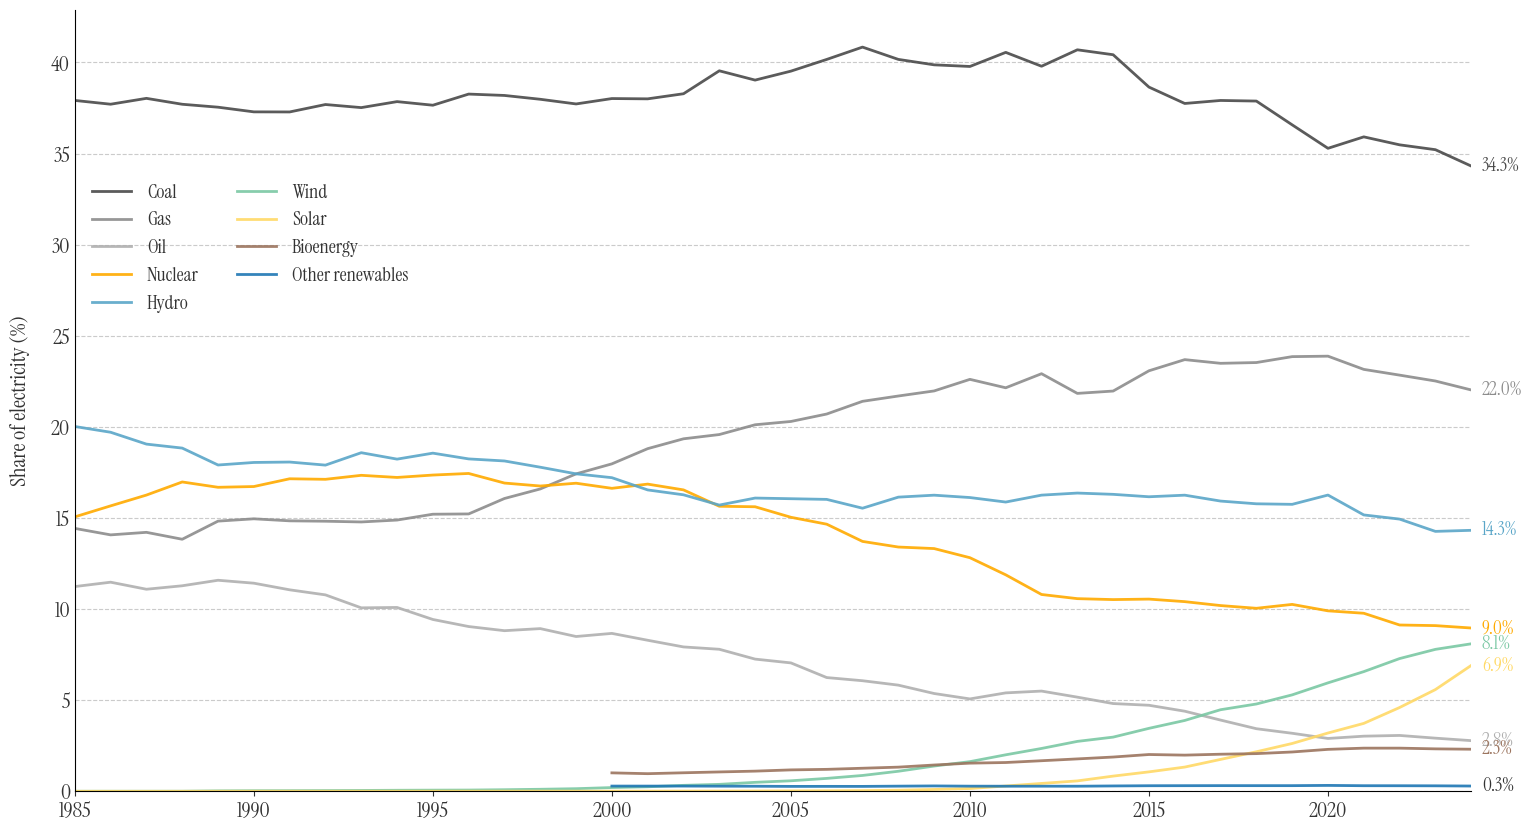

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from dotenv import load_dotenv
import os

# -----------------------------
# 1. Font setup
# -----------------------------
FONT_PATH = "./font.ttf"
fm.fontManager.addfont(FONT_PATH)
font_prop = fm.FontProperties(fname=FONT_PATH)
FONT_NAME = font_prop.get_name()

# -----------------------------
# 2. Load data
# -----------------------------
df = pd.read_csv("./data/share-elec-by-source.csv")
df_world = df[df["Entity"] == "World"].copy()

# -----------------------------
# 3. Select & clean source columns
# -----------------------------
SOURCE_COLUMNS = {
    "Coal - % electricity": "Coal",
    "Gas - % electricity": "Gas",
    "Oil - % electricity": "Oil",
    "Nuclear - % electricity": "Nuclear",
    "Hydro - % electricity": "Hydro",
    "Wind - % electricity": "Wind",
    "Solar - % electricity": "Solar",
    "Bioenergy - % electricity": "Bioenergy",
    "Other renewables excluding bioenergy - % electricity": "Other renewables",
}

df_sources = (
    df_world[["Year"] + list(SOURCE_COLUMNS.keys())]
    .rename(columns=SOURCE_COLUMNS)
    .sort_values("Year")
)

# -----------------------------
# 4. Color palette
# -----------------------------
load_dotenv("colors.env", override=True)
COLORS = {k: os.getenv(k.upper()) for k in SOURCE_COLUMNS.values()}
COLORS.update({"black": os.getenv("BLACK"), "white": os.getenv("WHITE")})

# -----------------------------
# 5. Global style
# -----------------------------
plt.rcParams.update({
    "font.family": FONT_NAME,
    "font.size": 16,
    "text.color": COLORS["black"],
    "axes.labelcolor": COLORS["black"],
    "xtick.color": COLORS["black"],
    "ytick.color": COLORS["black"],
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": COLORS["black"],
    "grid.linestyle": "--",
    "grid.alpha": 0.25,
})

# -----------------------------
# 6. Plot lines
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 9))

for col in df_sources.columns[1:]:
    ax.plot(
        df_sources["Year"],
        df_sources[col],
        label=col,
        color=COLORS[col],
        linewidth=2,
        alpha=0.9
    )

ax.set_xlim(df_sources["Year"].min(), df_sources["Year"].max())

# Automatically set y-limit to max value in the data + small padding
ymax = df_sources.iloc[:, 1:].max().max()  # max across all sources and years
ax.set_ylim(0, ymax * 1.05)  # 5% padding above the highest value

ax.set_ylabel("Share of electricity (%)", fontsize=16, labelpad=15)
ax.tick_params(axis="both", labelsize=16)
ax.tick_params(axis="y", length=0)
ax.grid(True, axis="y")

# -----------------------------
# 7. Legend
# -----------------------------
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0, 0.8),
    frameon=False,
    fontsize=14,
    ncol=2
)

# -----------------------------
# 8. Last-year labels
# -----------------------------
last_year = df_sources["Year"].iloc[-1]
last_values = df_sources.iloc[-1, 1:]

for i, col in enumerate(df_sources.columns[1:]):
    ax.text(
        last_year + 0.3,
        last_values[col],
        f"{last_values[col]:.1f}%",
        color=COLORS[col],
        fontsize=14,
        va='center'
    )

# -----------------------------
# 9. Export
# -----------------------------
plt.tight_layout(pad=2)
plt.savefig(
    "./global_share_of_electricity_by_source_lines.svg",
    format="svg",
    bbox_inches="tight",
    transparent=True
)
plt.show()
